<a href="https://colab.research.google.com/github/noruzzaman-rahat/Research-With-Machine-Learning/blob/main/DecisiontreeKNNLogisticRegression_Homework_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##  Assignment - 09

**Dataset:** [Cybersecurity Intrusion Detection Dataset](https://www.kaggle.com/datasets/dnkumars/cybersecurity-intrusion-detection-dataset)

Upload the dataset to your Google Drive under `datasets/` and complete the following tasks using the **same workflow** as this notebook.

| Task | What to do |
|------|------------|
| **1. Load & Inspect** | Load CSV, print shape, missing values, and class distribution |
| **2. Preprocess** | Drop irrelevant columns, fill missing values with median, scale features, split 80/20 |
| **3. EDA** | Bar chart of class distribution + top-10 feature correlations |
| **4. Train Models** | Decision Tree, KNN (k=5), Logistic Regression — report Accuracy, Precision, Recall, F1 |
| **5. Depth Tuning** | Decision Tree with max_depth = [3, 5, 10, 15, 20, None] — table + bar chart |
| **6. Evaluate** | Classification reports + 1×3 confusion matrix grid + model comparison bar chart |

**Submit:** Single `.ipynb` with all cells executed and clean output.

## 1. Imports & Setup


In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## 2. Data Loading


In [4]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/skill morph/cybersecurity_intrusion_data.csv')
print(f"Shape: {df.shape}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (9537, 11)


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


## 3. Data Inspection


In [6]:
missing = df.isnull().sum()
print("Missing values per column:\n", missing[missing > 0])
print("\nLabels:\n", df['attack_detected'].value_counts().sort_index())
print("\nClass mapping: 0=No Attack, 1=Attack Detected")

Missing values per column:
 encryption_used    1966
dtype: int64

Labels:
 attack_detected
0    5273
1    4264
Name: count, dtype: int64

Class mapping: 0=No Attack, 1=Attack Detected


## 4. Preprocessing & Train-Test Split


In [13]:
df.drop(columns=['session_id'], inplace=True, errors='ignore')

# Handle missing values in 'encryption_used' (categorical) by filling with mode
if 'encryption_used' in df.columns:
    df['encryption_used'] = df['encryption_used'].fillna(df['encryption_used'].mode()[0])

# Handle missing values for numerical columns (if any others exist) with median
df = df.fillna(df.median(numeric_only=True))

# One-hot encode categorical features, only if they exist
categorical_cols = ['encryption_used', 'protocol_type', 'browser_type']
existing_categorical_cols = [col for col in categorical_cols if col in df.columns]
df = pd.get_dummies(df, columns=existing_categorical_cols, drop_first=True, dtype=int)

X = df.drop(columns=['attack_detected'])
y = df['attack_detected']
X_scaled = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=20)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 7629 | Test: 1908


## 5. Exploratory Data Analysis (EDA)


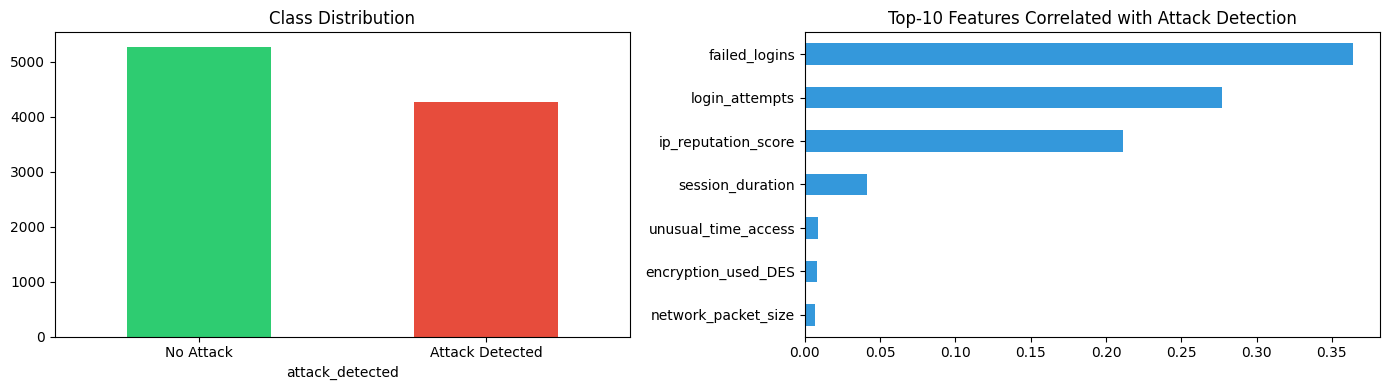

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# Update labels for the current dataset
labels = ['No Attack', 'Attack Detected']

df['attack_detected'].value_counts().plot.bar(ax=axes[0], color=['#2ecc71','#e74c3c'])
axes[0].set_xticklabels(labels, rotation=0);
axes[0].set_title('Class Distribution')

# Ensure 'attack_detected' is dropped before calculating correlations for features
df.corr(numeric_only=True)['attack_detected'].drop('attack_detected').abs().sort_values(ascending=False).head(10).plot.barh(ax=axes[1], color='#3498db')
axes[1].set_title('Top-10 Features Correlated with Attack Detection'); axes[1].invert_yaxis()
plt.tight_layout();
plt.show()

## 6. Model Training & Baseline Results


In [17]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=20),
    'KNN (k=5)':     KNeighborsClassifier(n_neighbors=5),
    'Logistic Reg':  LogisticRegression(max_iter=1000, random_state=20)
}
results, predictions = {}, {}

for name, m in models.items():
    m.fit(X_train, y_train)
    yp = m.predict(X_test)
    predictions[name] = yp
    results[name] = {
        'Accuracy':  accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall':    recall_score(y_test, yp, average='weighted'),
        'F1-Score':  f1_score(y_test, yp, average='weighted')
    }
    print(f"{name}: Acc={results[name]['Accuracy']:.4f}  Precision = {results[name]['Precision']:.4f} Recall = {results[name]['Recall']:.4f} F1={results[name]['F1-Score']:.4f}")


Decision Tree: Acc=0.7951  Precision = 0.7972 Recall = 0.7951 F1=0.7956
KNN (k=5): Acc=0.8218  Precision = 0.8257 Recall = 0.8218 F1=0.8190
Logistic Reg: Acc=0.7338  Precision = 0.7325 Recall = 0.7338 F1=0.7323


## 7. Decision Tree — Depth Tuning


           Accuracy  Precision  Recall  F1-Score
max_depth                                       
3            0.8852     0.9046  0.8852    0.8818
5            0.8873     0.9061  0.8873    0.8841
10           0.8779     0.8913  0.8779    0.8749
15           0.8595     0.8650  0.8595    0.8574
20           0.8396     0.8405  0.8396    0.8384
None         0.7951     0.7972  0.7951    0.7956


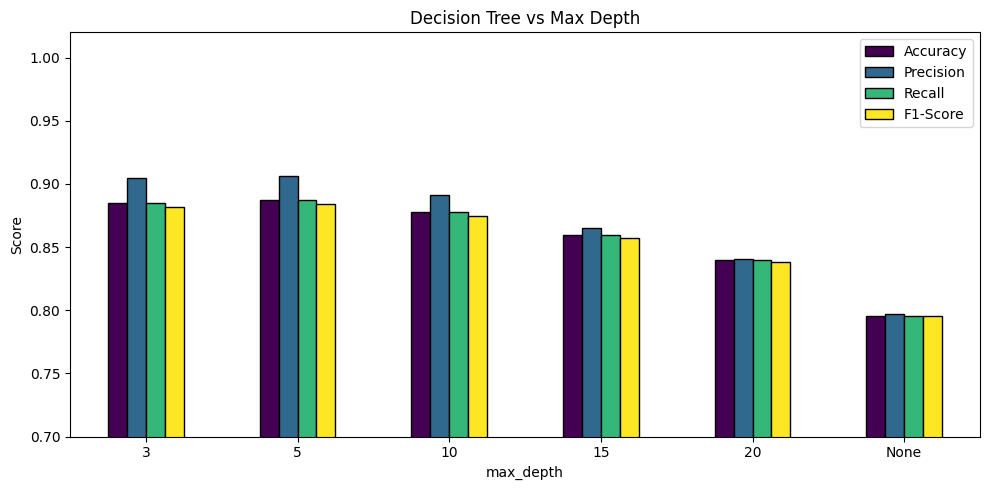

In [18]:
dt_results = []
for d in [3, 5, 10, 15, 20, None]:
    dt = DecisionTreeClassifier(max_depth=d, random_state=20).fit(X_train, y_train)
    yp = dt.predict(X_test)
    dt_results.append({'max_depth': str(d) or 'None',
        'Accuracy': accuracy_score(y_test, yp), 'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall': recall_score(y_test, yp, average='weighted'), 'F1-Score': f1_score(y_test, yp, average='weighted')})

dt_df = pd.DataFrame(dt_results).set_index('max_depth')
print(dt_df.round(4))
dt_df.plot(kind='bar', figsize=(10,5), colormap='viridis', edgecolor='black')
plt.title('Decision Tree vs Max Depth'); plt.ylabel('Score'); plt.ylim(0.7, 1.02); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## 8. Classification Reports


In [20]:
target_names = ['No Attack', 'Attack Detected']
for name, yp in predictions.items():
    print(f"\n{'='*55}\n{name}\n{'='*55}")
    print(classification_report(y_test, yp, target_names=target_names, digits=4))


Decision Tree
                 precision    recall  f1-score   support

      No Attack     0.8337    0.7957    0.8143      1077
Attack Detected     0.7500    0.7942    0.7715       831

       accuracy                         0.7951      1908
      macro avg     0.7918    0.7950    0.7929      1908
   weighted avg     0.7972    0.7951    0.7956      1908


KNN (k=5)
                 precision    recall  f1-score   support

      No Attack     0.8028    0.9071    0.8518      1077
Attack Detected     0.8553    0.7112    0.7766       831

       accuracy                         0.8218      1908
      macro avg     0.8290    0.8092    0.8142      1908
   weighted avg     0.8257    0.8218    0.8190      1908


Logistic Reg
                 precision    recall  f1-score   support

      No Attack     0.7498    0.7929    0.7708      1077
Attack Detected     0.7100    0.6570    0.6825       831

       accuracy                         0.7338      1908
      macro avg     0.7299    0.7250    

## 9. Confusion Matrices


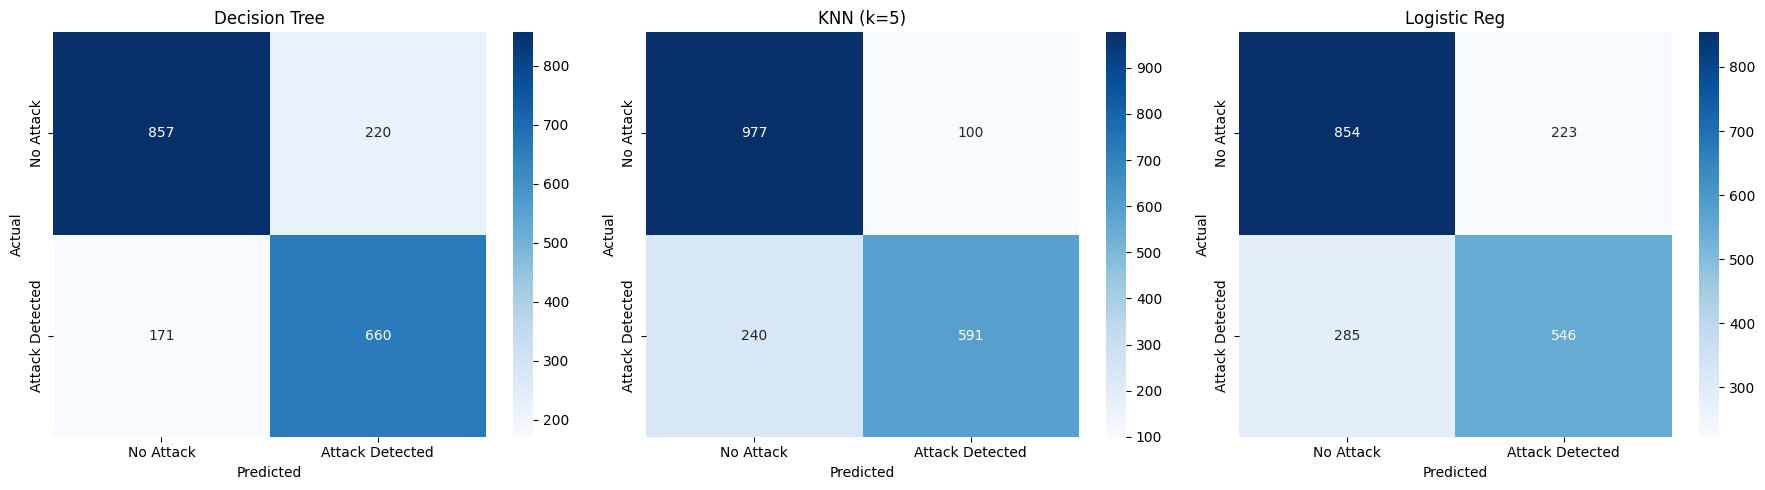

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, yp) in zip(axes, predictions.items()):
    sns.heatmap(confusion_matrix(y_test, yp), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=target_names, yticklabels=target_names)
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

## 10. Model Comparison


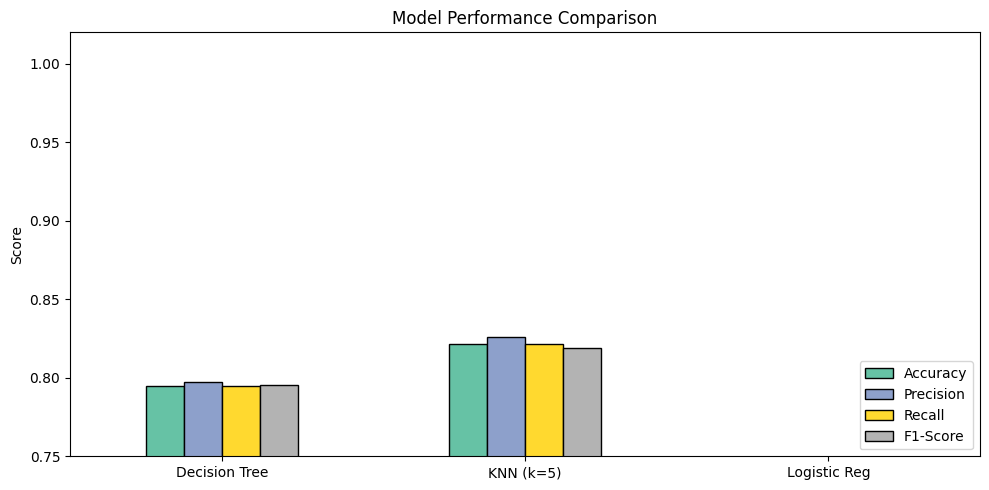


Summary:
                Accuracy  Precision  Recall  F1-Score
Decision Tree    0.7951     0.7972  0.7951    0.7956
KNN (k=5)        0.8218     0.8257  0.8218    0.8190
Logistic Reg     0.7338     0.7325  0.7338    0.7323


In [22]:
res_df = pd.DataFrame(results).T
res_df.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Model Performance Comparison'); plt.ylabel('Score'); plt.ylim(0.75, 1.02)
plt.xticks(rotation=0); plt.legend(loc='lower right'); plt.tight_layout(); plt.show()
print("\nSummary:\n", res_df.round(4))